In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("weather_forecast_data.csv")
df.head()

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain
0,23.720338,89.592641,7.335604,50.501694,1032.378759,rain
1,27.879734,46.489704,5.952484,4.990053,992.614190,no rain
2,25.069084,83.072843,1.371992,14.855784,1007.231620,no rain
3,23.622080,74.367758,7.050551,67.255282,982.632013,rain
4,20.591370,96.858822,4.643921,47.676444,980.825142,no rain


In [3]:
print(df.isnull().sum())
print("================================Another Syntax of isnull================================")
print(df.isna().isna())

Temperature    0
Humidity       0
Wind_Speed     0
Cloud_Cover    0
Pressure       0
Rain           0
dtype: int64
================================Another Syntax of isnull================================
      Temperature  Humidity  Wind_Speed  Cloud_Cover  Pressure   Rain
0           False     False       False        False     False  False
1           False     False       False        False     False  False
2           False     False       False        False     False  False
3           False     False       False        False     False  False
4           False     False       False        False     False  False
...           ...       ...         ...          ...       ...    ...
2495        False     False       False        False     False  False
2496        False     False       False        False     False  False
2497        False     False       False        False     False  False
2498        False     False       False        False     False  False
2499        False     Fals

In [4]:
print(df.duplicated().sum())
print(df.duplicated().value_counts())  # to check how many False or True

0
False    2500
Name: count, dtype: int64


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

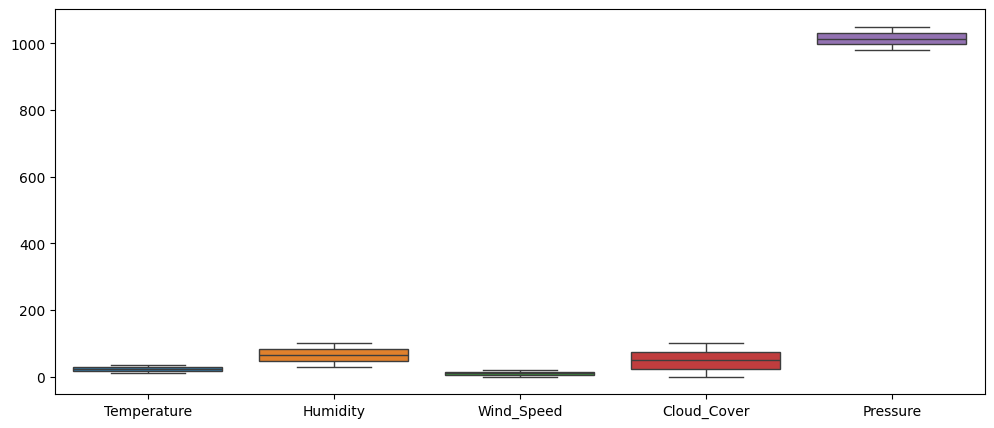

In [6]:
plt.figure(figsize=(12, 5))

# Plot the boxplot using seaborn
sns.boxplot(data=df)

# Show the plot
plt.show()

In [7]:
df['Rain'].value_counts()

Rain
no rain    2186
rain        314
Name: count, dtype: int64

In [8]:
df.columns

Index(['Temperature', 'Humidity', 'Wind_Speed', 'Cloud_Cover', 'Pressure',
       'Rain'],
      dtype='object')

In [9]:
print(type(df.columns))

<class 'pandas.core.indexes.base.Index'>


In [10]:
# Statistical Summary
df.describe()

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,22.581725,64.347094,9.906255,49.658104,1014.312336
std,7.326996,19.954739,5.780316,29.123104,20.196433
min,10.001842,30.005071,0.009819,0.015038,980.014486
25%,16.359398,47.339815,4.761909,23.900016,996.938630
50%,22.536448,63.920797,9.908572,49.488284,1013.433035
75%,28.976476,81.561021,14.948408,75.324140,1031.735067
max,34.995214,99.997481,19.999132,99.997795,1049.985593


In [11]:
# Summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  2500 non-null   float64
 1   Humidity     2500 non-null   float64
 2   Wind_Speed   2500 non-null   float64
 3   Cloud_Cover  2500 non-null   float64
 4   Pressure     2500 non-null   float64
 5   Rain         2500 non-null   object 
dtypes: float64(5), object(1)
memory usage: 117.3+ KB


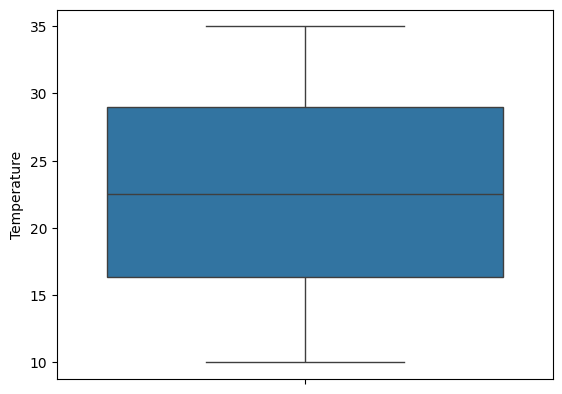

In [12]:
# plt.figure(figsize=(12, 5))
# Plot the boxplot using seaborn
sns.boxplot(data=df['Temperature'])

# Show the plot
plt.show()

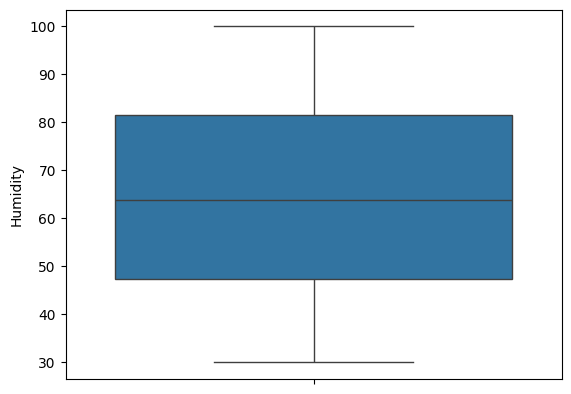

In [13]:
sns.boxplot(data=df['Humidity'])

# Show the plot
plt.show()

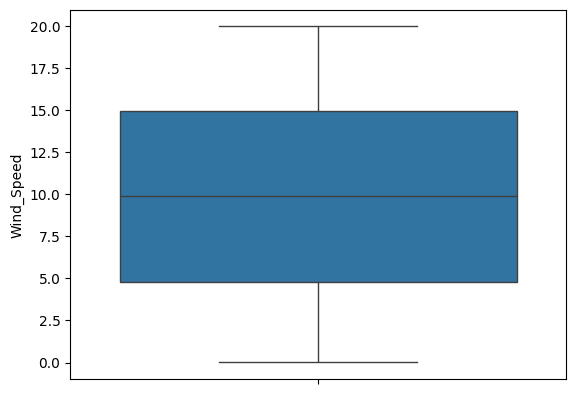

In [14]:
sns.boxplot(data=df['Wind_Speed'])

# Show the plot
plt.show()

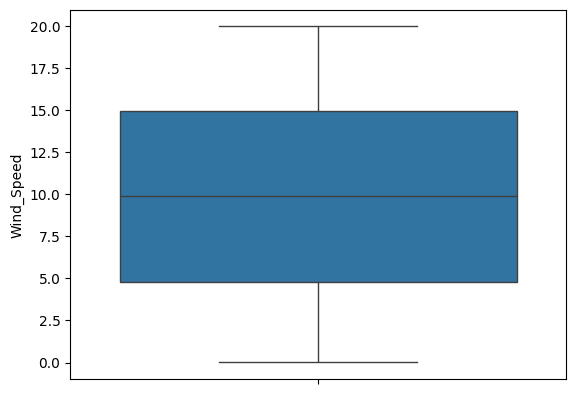

In [15]:
sns.boxplot(data=df['Wind_Speed'])

# Show the plot
plt.show()

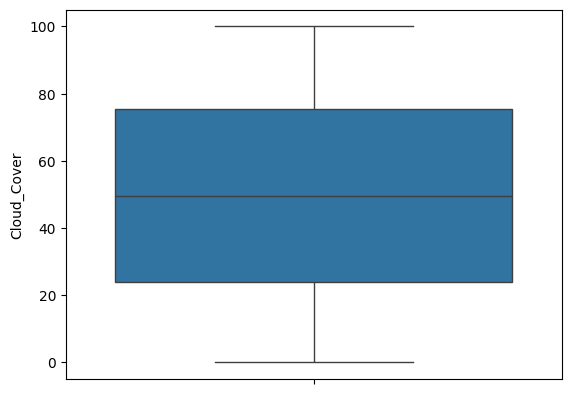

In [16]:
sns.boxplot(data=df['Cloud_Cover'])

# Show the plot
plt.show()

In [17]:
df['Rain'].value_counts()  # there is two classes in dataset in Rain

Rain
no rain    2186
rain        314
Name: count, dtype: int64

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix  #, classification_report, roc_auc_score, roc_curve

In [19]:
x = df[['Temperature', 'Humidity', 'Wind_Speed', 'Cloud_Cover', 'Pressure']]
y = df['Rain']

In [20]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [21]:
s = StandardScaler()
s

StandardScaler()

In [41]:
x_train = s.fit_transform(x_train)
x_test = s.transform(x_test)

In [47]:
model = LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [55]:
y_pred = model.predict(x_test)

In [61]:
accuracy = accuracy_score(y_test,y_pred)
accuracy

0.932

In [67]:
conf_matrix = confusion_matrix(y_test,y_pred)
conf_matrix

array([[430,  13],
       [ 21,  36]], dtype=int64)

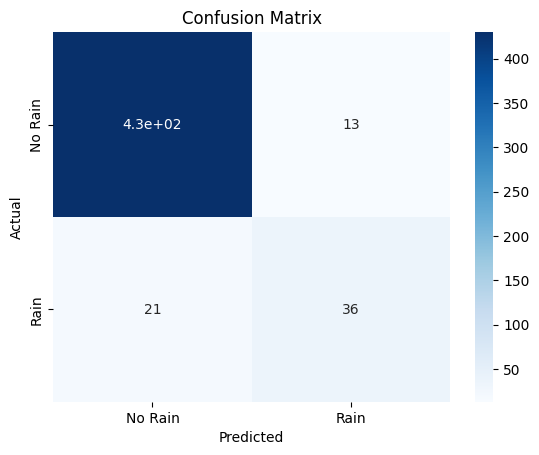

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(conf_matrix,annot=True,cmap='Blues',xticklabels=["No Rain","Rain"],yticklabels=['No Rain','Rain'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()